In [2]:
#Making graph

def prepareEdge(edge, source, destination):
    if (len(edge) == 0):
        edge.append((source, destination, 1));
    insertIndex = -1;
    for i in range(0, len(edge)):
        if (edge[i][0] == source and edge[i][1] == destination):
            insertIndex = i;
    if (insertIndex != -1):
        edge[insertIndex]=(edge[insertIndex][0], edge[insertIndex][1], edge[insertIndex][2]+1)
    else:
        edge.append((source, destination, 1))
    return edge



count = 1

file = open('../Dataset/CAR-HACKING DATASET FOR INTRUSION/Spoofing the drive gear.csv', 'r')
f= open("../Graph and Features/SpoofingAttackGraph_drive_gear.txt","w+")
msgIDs = {};
edge = []
prev = ''
s = '';
attacked = 0;
counter1 = 0
counter2 = noOfMessages = 200

for line in file:
# for i in range(1600):
#     line = file.readline()
    #print(line)

    if (count%noOfMessages == 1):
        Xpartition = line.split()[0].split(',');
        #print(Xpartition)
        prev = Xpartition[1]
        
        first_timestamp = Xpartition[0]# 用于记录每组数据的第一条消息的时间戳
    
    Xpartition = line.split()[0].split(',');
    if (Xpartition[1] in msgIDs.keys()):
        msgIDs[Xpartition[1]] += 1;
    else:
        msgIDs[Xpartition[1]] = 1;
    if (prev != '' and count != 1):
#         temp = (prev, Xpartition[1], 1);
        #edge.append(temp);
        if(prev != Xpartition[1]):
         edge =prepareEdge(edge, prev, Xpartition[1])
         prev = Xpartition[1]
    if (Xpartition[len(Xpartition)-1] == 'T'):
        attacked = count;
        #print(attacked)
    if (count%noOfMessages == 0):
        last_timestamp = Xpartition[0]# 用于记录每组数据的最后一条消息的时间戳
        #求得时间差
        time_difference = float(last_timestamp) - float(first_timestamp)
        s+= 'Graph Number ' + str(int(count/noOfMessages)) + ':\n';
        
        if (counter1 < attacked and attacked <= counter2 ):
            s+= 'Attack Free: ' 'False ' + str(attacked) + ' Time Difference: ' + str(time_difference) + '\n';
        else:
            s+= 'Attack Free: ' 'True ' + str(attacked) + ' Time Difference: ' + str(time_difference) + '\n';
        counter1+=noOfMessages
        counter2+=noOfMessages
        for key in msgIDs:
            s+= str(key) + ' --> ';
            for i in range(0, len(edge)):
                if(key == edge[i][0]):
                    s+= edge[i][1] + ' '
            s+= '\n'
        msgIDs = {};
        edge = [];
    count +=1
    
f.write(s)
f.close()

In [3]:
## 导入必要的库
import networkx as nx  # 用于处理网络图的库
import hashlib  # 用于生成哈希值的库
import numpy as np  # 用于数值计算的库

# 创建两个有向图，用于表示被攻击的网络和未被攻击的网络
gAttacked = nx.DiGraph()
gAttackfree = nx.DiGraph()

# 定义一个函数，用于获取攻击和未攻击的图的信息
def getAttackFreelist(filename):
    # 创建一个空列表，用于存储图的信息
    attacFreekList = []
    # 打开指定文件
    file_ = open(filename, 'r')

    # 初始化计数器，用于追踪图的数量
    graphCounter = 0
    while True:
        # 逐行读取文件
        line = file_.readline()
        # 如果已经到达文件末尾，退出循环
        if not line:
            break

        # 从行中提取前5个字符，通常是"Graph"，用于标识新的图开始
        graph_number = line[0:5]

        if graph_number == "Graph":
            # 增加图计数器
            graphCounter += 1
            # 读取下一行，通常包含图的信息，将其分割为列表并添加到attacFreekList中
            line = file_.readline()
            attacFreekList.append(line.split())

    # 关闭文件
    file_.close()

    # 打印信息，包括图的数量和每个图的信息
    print(len(attacFreekList))
    print(attacFreekList)
    # 返回包含图信息的列表
    return attacFreekList

# 定义一个函数，用于提取图的特征
def getFeatures(filename):
    # 调用getAttackFreelist函数获取攻击和未攻击图的信息，并存储在attackFreeList中
    attackFreeList = getAttackFreelist(filename)
    # 打开文件以读取数据
    file_ = open(filename, 'r')

    # 初始化用于存储图的列表
    graphList = []
    ultimate_graphList = []
    # 初始化图计数器
    graphCounter = 0
    while True:
        # 逐行读取文件
        line = file_.readline()
        # 如果已经到达文件末尾，退出循环
        if not line:
            break

        # 从行中提取前5个字符，通常是"Graph"，用于标识新的图开始
        graph_number = line[0:5]

        if graph_number == "Graph":
            # 增加图计数器
            graphCounter += 1
            # 读取下两行，通常包含图的信息，将其分割为列表并添加到ultimate_graphList中
            line = file_.readline()
            line = file_.readline()

            # 如果图计数器大于等于2，表示已经读取完前一个图的信息，将其添加到ultimate_graphList中
            if graphCounter >= 2:
                ultimate_graphList.append(graphList)
                graphList = []

        # 将每行数据以空格分割成列表，然后将列表添加到graphList中
        list1 = line.split()
        graphList.append(list1)

    # 将最后一个图的信息添加到ultimate_graphList中
    ultimate_graphList.append(graphList)
#     print(ultimate_graphList[0])
    # 关闭文件
    file_.close()
#     print(ultimate_graphList[0][1])#['02b0', '-->', '0002', '0430']
#     print(graphCounter)

    # 初始化用于存储所有特征的列表
    list_All_Feature_Set = []
    
    # 生成一个文件名，用于将特征写入新文件
    filetowrite = filename[:-4] + "_GraphFeatures.txt"
    # 打开一个新文件以写入特征
    file1 = open(filetowrite, 'w')

    # 获取图的总数
    graphNumber = len(ultimate_graphList)
#     print(graphNumber) 2831


    # 迭代每个图
    for i in range(0, graphNumber):
        # 创建一个有向图对象
        G = nx.DiGraph()
        
        # 获取当前图顶点数
        graphVertexNumber = len(ultimate_graphList[i])

        # 遍历每个顶点
        for j in range(0, graphVertexNumber):
            # 当前边的长度，['02b0', '-->', '0002', '0430']长度为4
            vertexConnectionLength = len(ultimate_graphList[i][j])
#             print(vertexConnectionLength)
#             break
            # 遍历连接，将节点和它们的关系添加到图G中
            for k in range(2, vertexConnectionLength):#因为0 1对应的不是边 2开始才是边
                if(ultimate_graphList[i][j][0] == ultimate_graphList[i][j][k]):############
                    continue
                G.add_edge(ultimate_graphList[i][j][0], ultimate_graphList[i][j][k])
                
                if i == 1:#用于之后的构图例子所以在这里提取一个图到gAttackfree，由于数据集中i=1时对应的第2个图未受攻击
                    if(ultimate_graphList[i][j][0] == ultimate_graphList[i][j][k]):
                     continue
                    gAttackfree.add_edge(ultimate_graphList[i][j][0], ultimate_graphList[i][j][k])
                
                if i == 10:#用于之后的构图例子所以在这里提取一个图到 gAttacked 由于数据集中i=10时对应的第11个图受攻击
                    if(ultimate_graphList[i][j][0] == ultimate_graphList[i][j][k]):
                     continue
                    gAttacked.add_edge(ultimate_graphList[i][j][0], ultimate_graphList[i][j][k])
#                     print(list(gAttacked))

        # 获取图的边数和节点数
        edge = G.number_of_edges()
        node = G.number_of_nodes()

        # 计算介数中心性
        betweenness_centrality = nx.betweenness_centrality(G)
#         # 计算特征向量中心性
#         eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=500, tol=1e-4)
        # 获取介数中心性和向量中心性的值
        betweenness_values = list(betweenness_centrality.values())
#         eigenvector_values = list(eigenvector_centrality.values())

        # 计算介数中心性和向量中心性的中值
        max_betweenness = np.max(betweenness_values)
#         max_eigenvector = np.max(eigenvector_values)

        #图的密度
        density = nx.density(G)
#         #强联通分量
#         strongly_connected_components = list(nx.strongly_connected_components(G))
#         num_strongly_connected_components = len(strongly_connected_components)


        # 如果i等于0，表示第一个图之前将特征的标题写入文件
        if i == 0:
            file1.write("No." + "\t" + "Nodes\t" + "Edges\t" + "MaximumIndegree\t"  + "MinimumIndegree\t" +
                        "MaximumOutdegree\t"  + "MinimumOutdegree\t"  + "Time Difference\t" +
                        "max_betweenness_centrality\t" + "density\t" + 
                        "State\n")

        # 写入特征信息到文件
        file1.write(str(i + 1) + "\t")
        counter = 0
        in_deg = []
        out_deg = []
        for j in range(0, graphVertexNumber):
            in_deg.append(G.in_degree(ultimate_graphList[i][j][0]))
            out_deg.append(G.out_degree(ultimate_graphList[i][j][0]))
        
        maxInd = np.max(in_deg)
        minInd = np.min(in_deg)
        maxOut = np.max(out_deg)
        minOut = np.min(out_deg)
        file1.write(str(node) + "\t") 
        file1.write(str(edge) + "\t")
        file1.write(str(maxInd) + str("\t") + str(minInd)+ str("\t"))
        file1.write(str(maxOut) + str("\t") + str(minOut)+ str("\t"))       
        file1.write(str(attackFreeList[i][6]) + str("\t"))
        file1.write(str(max_betweenness) + str("\t") +
                    str(density) + str("\t")  +
                    str(attackFreeList[i][2]) + "\n")


    # 关闭文件
    file1.close()

# 调用getFeatures函数来处理指定的文件
getFeatures('../Graph and Features/SpoofingAttackGraph_drive_gear.txt')

print(list(gAttackfree))
print(list(gAttacked))

22215
[['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.10837602615356445'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.10932087898254395'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.1086568832397461'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.10737299919128418'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.10335588455200195'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.1082010269165039'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.10909509658813477'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.1092991828918457'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.1035759449005127'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.10424613952636719'], ['Attack', 'Free:', 'False', '2200', 'Time', 'Difference:', '0.17953896522521973'], ['Attack', 'Free:', 'False', '2399', 'Time', 'Difference:', '0.08674001693725586'], ['Attack', 'Free:', 'False', 

['0329', '0545', '0430', '02c0', '0130', '05f0', '043f', '0350', '0370', '0440', '04f0', '0316', '00a0', '0690', '018f', '0260', '0002', '02a0', '04b1', '01f1', '0153', '0131', '0140', '00a1']
['0140', '02c0', '05f0', '0350', '0130', '0370', '043f', '0316', '00a0', '018f', '0440', '04f0', '0430', '04b1', '0545', '0153', '0690', '0329', '0260', '02a0', '0002', '0131', '01f1']


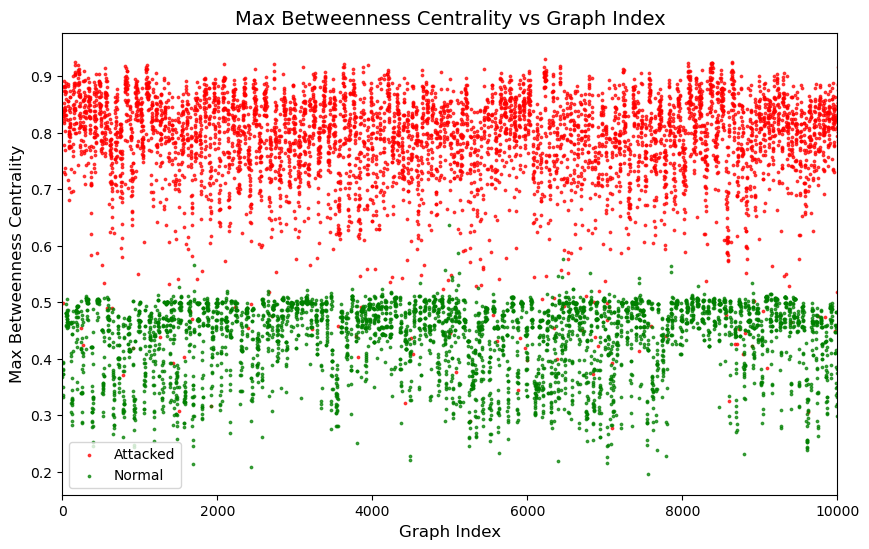

In [9]:
import pandas as pd  
import matplotlib.pyplot as plt  

# 读取数据集  
dataframe = pd.read_table('../Graph and Features/SpoofingAttackGraph_drive_gear_GraphFeatures.txt')  

# 提取所需列  
x = dataframe.iloc[:, 0]  # 第一列：序号  
y = dataframe.iloc[:, 8]  # 第九列：max betweenness centrality  
labels = dataframe.iloc[:, 10]  # 第十一列：标签  

# 绘图  
plt.figure(figsize=(10, 6))  

# 绘制标签为 False 的点（红色），点大小设置为20  
plt.scatter(x[labels == False], y[labels == False], color='red', label='Attacked', alpha=0.7, s=3)  

# 绘制标签为 True 的点（绿色），点大小设置为20  
plt.scatter(x[labels == True], y[labels == True], color='green', label='Normal', alpha=0.7, s=3)  

# 设置 x 轴范围为 0 到 10000  
plt.xlim(0, 10000)  

# 添加标题和标签  
plt.title('Max Betweenness Centrality vs Graph Index', fontsize=14)  
plt.xlabel('Graph Index', fontsize=12)  
plt.ylabel('Max Betweenness Centrality', fontsize=12)  

# 添加图例  
plt.legend()  

# 显示图形  
plt.show()

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt
import pandas
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



# load dataset
dataframe = pandas.read_table('../Graph and Features/SpoofingAttackGraph_drive_gear_GraphFeatures.txt')
dataframe_attfree = pandas.read_table('../Graph and Features/AttackFreeGraph_GraphFeatures.txt')
dataframe_attfree_otids = pandas.read_table('../Graph and Features/AttackFreeGraph_OTIDS_GraphFeatures.txt')
dataframe_attfree_opel = pandas.read_table('../Graph and Features/AttackFreeGraph_Opel_GraphFeatures.txt')
# 将四个数据集按行合并
combined_data = pandas.concat([dataframe, dataframe_attfree,dataframe_attfree_otids, dataframe_attfree_opel], ignore_index=True)

data = combined_data.drop("No.", axis=1)
dataset = data.values


l = 22215 + 4944 + 11846 + 13450
X = dataset[:,0:]
# print(X.shape)
labels = []
counter1 = 0
counter2 = 0
for i in range (0,l):
  if X[i][9] == True:
    labels.append(1)
    counter1 += 1
  else:
    labels.append(-1)
    counter2 += 1

features = X[0:l,0:9]



# 假设X是你的数据集，y是对应的标签（1代表未受攻击，-1代表受到攻击）

X_train, X_test, y_train, y_test = train_test_split(features,
                                                            labels,
                                                            test_size=0.3,
                                                            random_state= 42)#
# 创建决策树分类器
clf = DecisionTreeClassifier(random_state=42, max_depth=7)

# 在训练集上训练决策树分类器
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"准确率: {accuracy:.10f}")

# 计算精确率
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])

# 计算召回率
recall = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])

# 计算 F1 分数
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"精确率: {precision:.10f}")
print(f"召回率: {recall:.10f}")
print(f"F1 分数: {f1_score:.10f}")

print("混淆矩阵:")
print(conf_matrix)

print(counter1,counter2,counter1 +counter2)

准确率: 0.9978394866
精确率: 0.9978107897
召回率: 0.9995300752
F1 分数: 0.9986696925
混淆矩阵:
[[ 2941    28]
 [    6 12762]]
42728 9727 52455


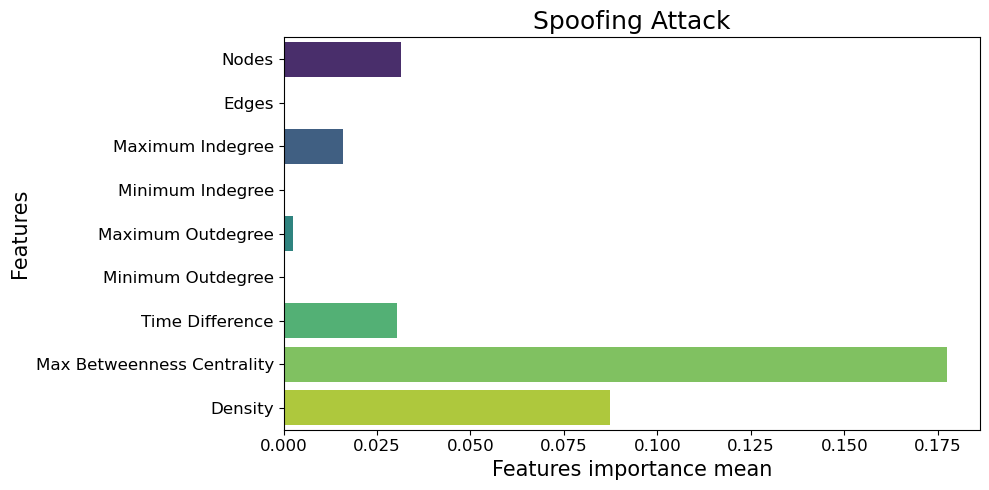

In [21]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

def plot_feature_importance(X, labels):
    features = X[:, 0:9]
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3)
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    imps = permutation_importance(clf, X_test, y_test)
    feature_names = ["Nodes", "Edges", "Maximum Indegree", "Minimum Indegree", "Maximum Outdegree",
                     "Minimum Outdegree", "Time Difference", "Max Betweenness Centrality", "Density"]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=imps.importances_mean, y=feature_names, palette='viridis')
    plt.xlabel('Features importance mean', fontsize=15)
    plt.ylabel('Features', fontsize=15)
    plt.title('Spoofing Attack', fontsize=18)
    plt.tick_params(labelsize=12)
    plt.tight_layout()
    plt.savefig('../PNG/spoofy/spoofy_Feature Importance Analysis_drive_gear_Merge.png', bbox_inches='tight')
    plt.show()

# 假设X和labels已被定义
plot_feature_importance(X, labels)


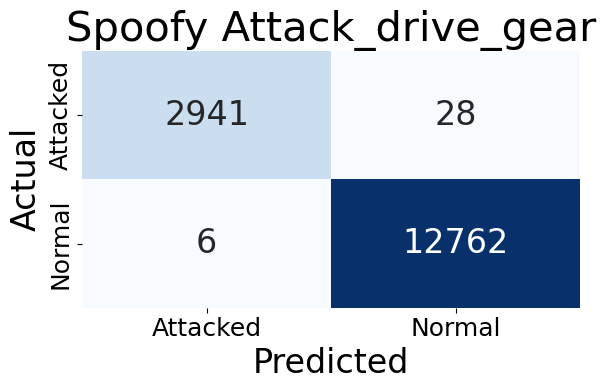

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 创建混淆矩阵


# 调整图形大小
plt.figure(figsize=(6, 4))
# 标签
tick_labels = ['Attacked', 'Normal']
# 使用 Seaborn 绘制热力图
hm = sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',annot_kws={"size": 24},xticklabels=tick_labels, yticklabels=tick_labels,
                cbar=False)
plt.xlabel('Predicted', fontsize=24)
plt.ylabel('Actual', fontsize=24)
plt.title('Spoofy Attack_drive_gear',fontsize=30)
# 设置标签字体大小
hm.set_xticklabels(hm.get_xticklabels(), fontsize=18)
hm.set_yticklabels(hm.get_yticklabels(), fontsize=18)

plt.tight_layout()  # 调整布局，确保图形完整显示
plt.savefig('../PNG/spoofy/confusion_matrix_drive_gear_Merge.png', dpi=600)
plt.show()


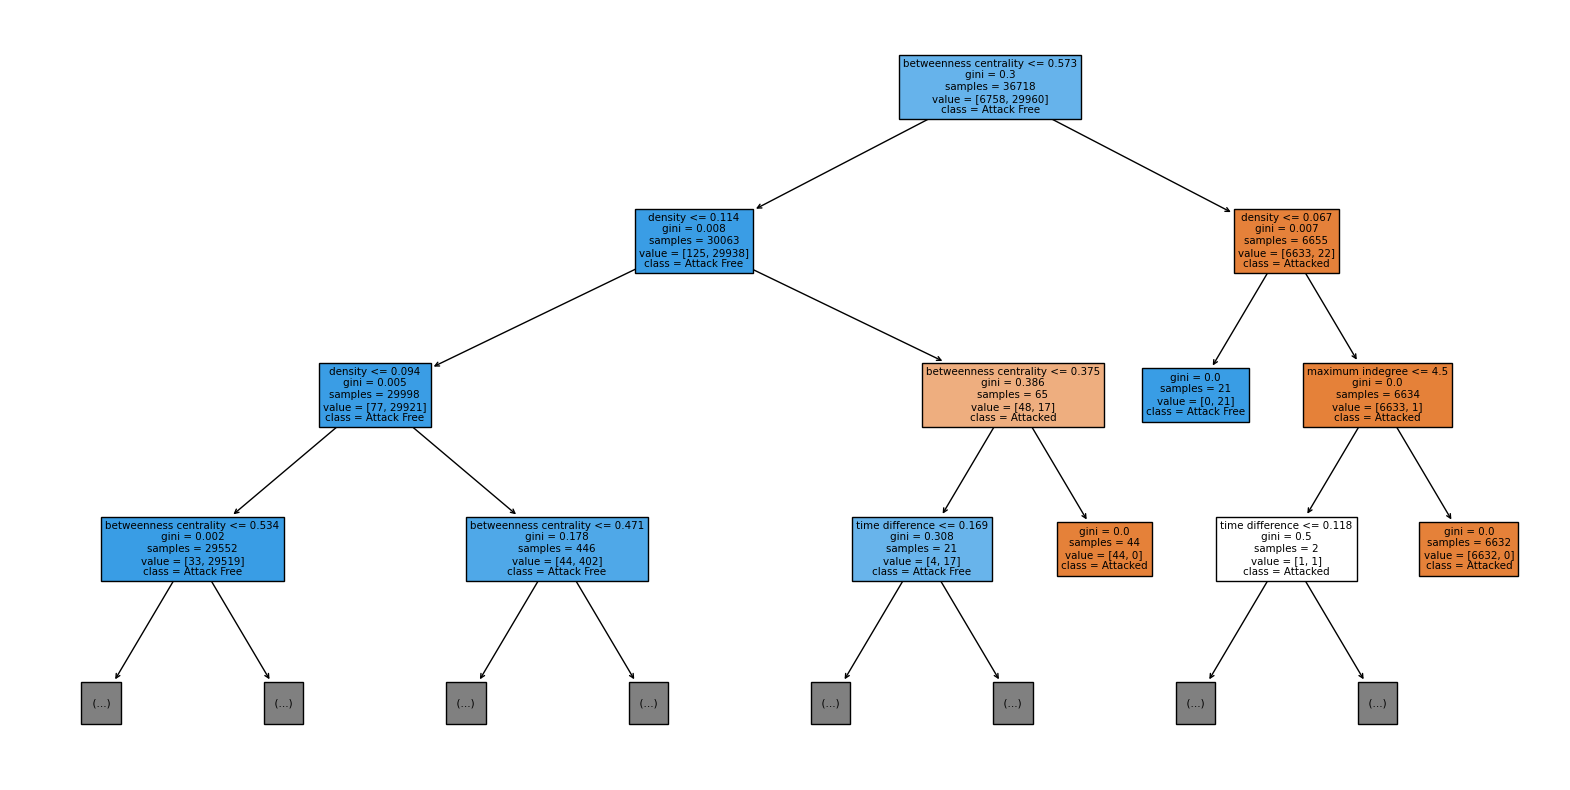

<Figure size 640x480 with 0 Axes>

In [59]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
feature_names = ["nodes", "edges", "maximum indegree", "minimum indegree", "maximum Outdegree",
                     "minimum Outdegree", "time difference", "betweenness centrality", "density"]
plt.figure(figsize=(20, 10))  # 调整图形大小以适应显示
plot_tree(clf, max_depth=3, filled=True, feature_names=feature_names, class_names=["Attacked", "Attack Free"])
plt.show()
plt.savefig('../PNG/spoofy/DecisionTree_drive_gear.png',  bbox_inches='tight')

# from sklearn.tree import export_text

# tree_rules = export_text(clf, feature_names= feature_names)
# print(tree_rules)